In [19]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset och preprocessing
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

X shape: (2000, 2)
y shape: (2000,)
Klasser: [0 1]


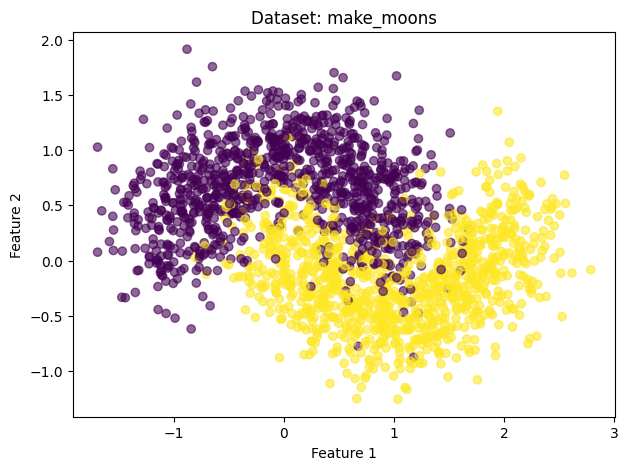

In [20]:
X, y = make_moons(
    n_samples=2000,
    noise=0.30,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Klasser:", np.unique(y))

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset: make_moons")
plt.show()

In [21]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    train_size=250,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (250, 2)
Validation: (1250, 2)
Test: (500, 2)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [23]:
def build_model(
    hidden_layers=5,
    hidden_units=128,
    learning_rate=0.001,
    dropout_rate=0.0,
    l2_strength=0.0
):
    """
    Bygger och kompilerar en neural nätverksmodell.

    hidden_layers:
        Antal dolda lager. Fler lager ger ofta högre modellkapacitet.

    hidden_units:
        Antal neuroner per dolt lager.

    learning_rate:
        Hur stora steg optimizer tar när vikterna uppdateras.

    dropout_rate:
        Andel neuroner som slumpmässigt stängs av under träning.
        0.0 betyder ingen dropout.

    l2_strength:
        Styrkan på L2-regularisering.
        0.0 betyder ingen L2-regularisering.
    """

    # Om l2_strength är större än 0 använder vi L2-regularisering.
    # Annars sätter vi regularizer till None.
    kernel_regularizer = (
        regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = keras.Sequential()
    model.add(layers.Input(shape=(2,)))

    for _ in range(hidden_layers):
        model.add(
            layers.Dense(
                hidden_units,
                activation="relu",
                kernel_regularizer=kernel_regularizer
            )
        )

        # Dropout används bara om dropout_rate är större än 0.
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [24]:
def plot_history(history, title="Träningskurvor"):
    """
    Plottar loss och accuracy för både training och validation.

    history:
        Objektet som returneras från model.fit().

    title:
        Rubrik för grafen.
    """

    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.show()

In [25]:
def plot_decision_boundary(model, X_original, y_original, title="Beslutsgräns"):
    """
    Visualiserar modellens beslutsgräns i 2D.

    model:
        Tränad Keras-modell.

    X_original:
        Oskalad X-data. Vi använder oskalad data för att rita grafen i originalskalan.

    y_original:
        Sanna klasser.

    title:
        Rubrik för grafen.
    """

    x_min, x_max = X_original[:, 0].min() - 0.5, X_original[:, 0].max() + 0.5
    y_min, y_max = X_original[:, 1].min() - 0.5, X_original[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Modellen tränades på skalad data, så grid måste skalas med samma scaler.
    grid_scaled = scaler.transform(grid)

    proba = model.predict(grid_scaled, verbose=0).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, proba, levels=50, alpha=0.7)
    plt.scatter(X_original[:, 0], X_original[:, 1], c=y_original, edgecolor="k", alpha=0.8)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

In [26]:
def run_experiment(
    name,
    model,
    epochs=300,
    batch_size=32,
    callbacks=None,
    verbose=0
):
    """
    Tränar, utvärderar och visualiserar en modell.

    name:
        Namn på experimentet.

    model:
        Keras-modellen som ska tränas.

    epochs:
        Max antal epoker.

    batch_size:
        Batch size under träning.

    callbacks:
        Lista med callbacks, till exempel EarlyStopping.

    verbose:
        0 = tyst träning, 1 = progressbar.
    """

    print(f"\nExperiment: {name}")
    start_time = time.time()

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )

    print(f"Antal tränade epoker: {len(history.history['loss'])}")
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Träningstid: {training_time:.2f} sekunder")

    plot_history(history, title=name)

    result = {
        "experiment": name,
        "epochs_trained": len(history.history["loss"]),
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "training_time": training_time
    }

    return history, result


Experiment: Stor modell utan regularisering
Antal tränade epoker: 300
Test loss: 0.7845
Test accuracy: 0.8920
Träningstid: 27.53 sekunder


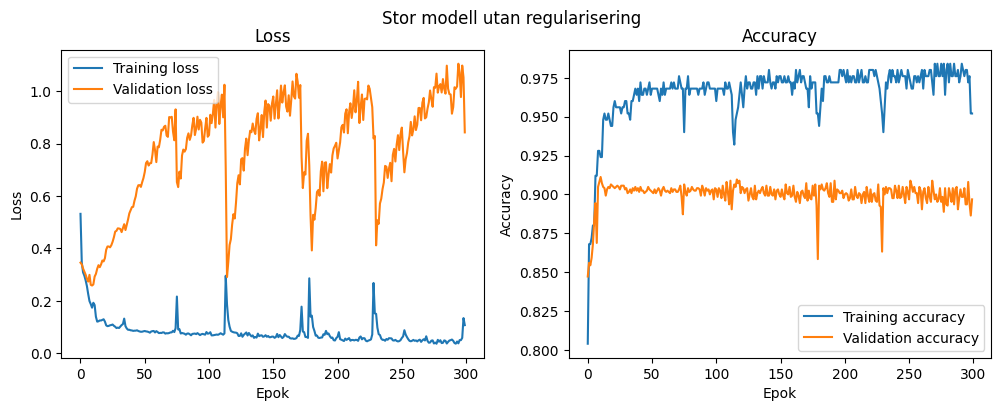

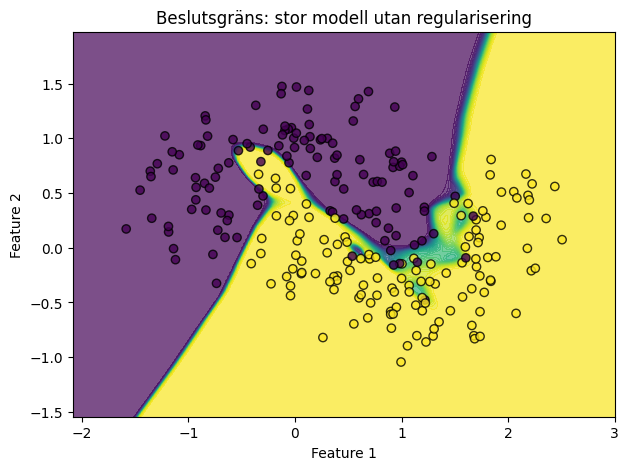

In [27]:
results = []

overfit_model = build_model(
    hidden_layers=5,
    hidden_units=128,
    learning_rate=0.001,
    dropout_rate=0.0,
    l2_strength=0.0
)

overfit_history, overfit_result = run_experiment(
    name="Stor modell utan regularisering",
    model=overfit_model,
    epochs=300,
    batch_size=16,
    callbacks=None,
    verbose=0
)

results.append(overfit_result)

plot_decision_boundary(
    overfit_model,
    X_train,
    y_train,
    title="Beslutsgräns: stor modell utan regularisering"
)


Experiment: Samma modell med early stopping
Antal tränade epoker: 32
Test loss: 0.2626
Test accuracy: 0.9000
Träningstid: 3.43 sekunder


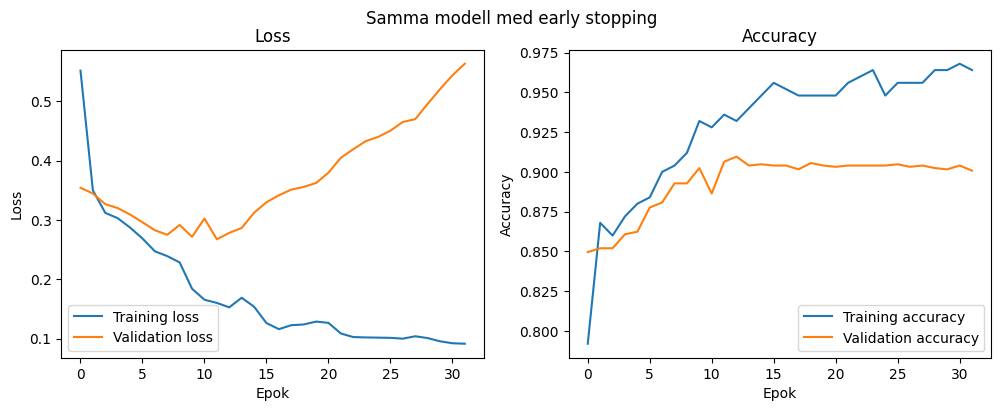

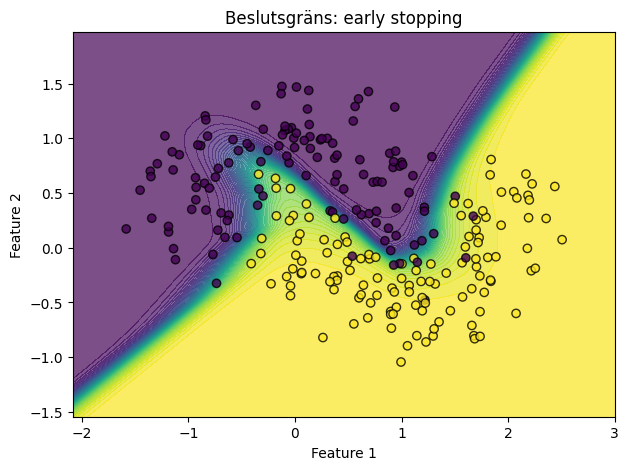

In [28]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

early_stop_model = build_model(
    hidden_layers=5,
    hidden_units=128,
    learning_rate=0.001,
    dropout_rate=0.0,
    l2_strength=0.0
)

early_stop_history, early_stop_result = run_experiment(
    name="Samma modell med early stopping",
    model=early_stop_model,
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0
)

results.append(early_stop_result)

plot_decision_boundary(
    early_stop_model,
    X_train,
    y_train,
    title="Beslutsgräns: early stopping"
)


Experiment: Stor modell med dropout
Antal tränade epoker: 42
Test loss: 0.2518
Test accuracy: 0.8940
Träningstid: 4.73 sekunder


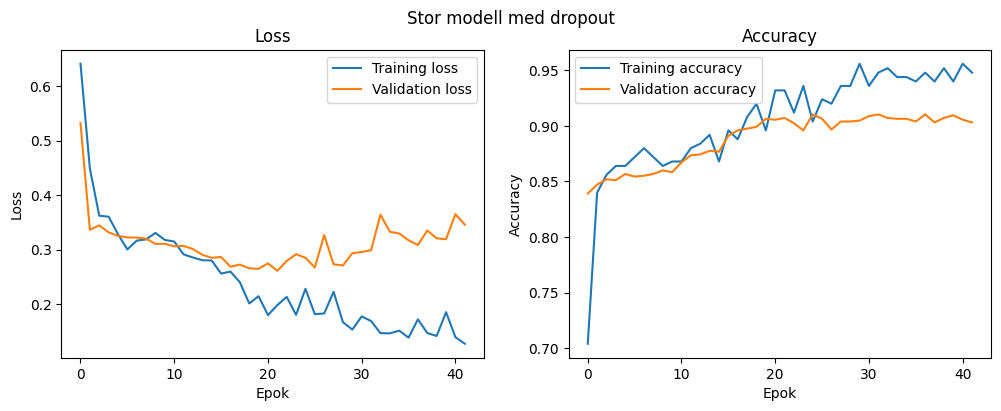

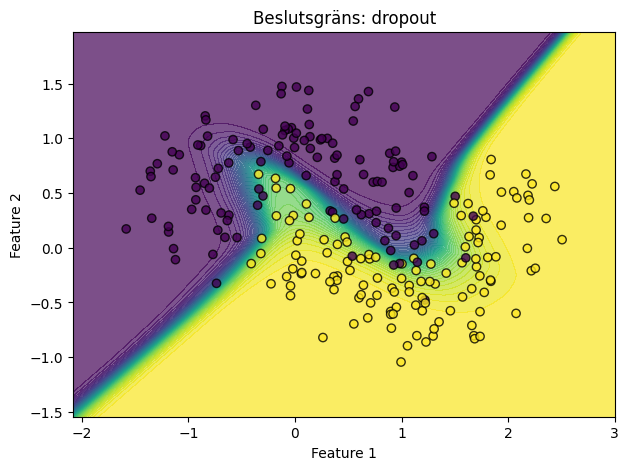

In [29]:
dropout_model = build_model(
    hidden_layers=5,
    hidden_units=128,
    learning_rate=0.001,
    dropout_rate=0.30,
    l2_strength=0.0
)

dropout_history, dropout_result = run_experiment(
    name="Stor modell med dropout",
    model=dropout_model,
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0
)

results.append(dropout_result)

plot_decision_boundary(
    dropout_model,
    X_train,
    y_train,
    title="Beslutsgräns: dropout"
)


Experiment: Stor modell med L2-regularisering
Antal tränade epoker: 20
Test loss: 0.8377
Test accuracy: 0.8660
Träningstid: 2.42 sekunder


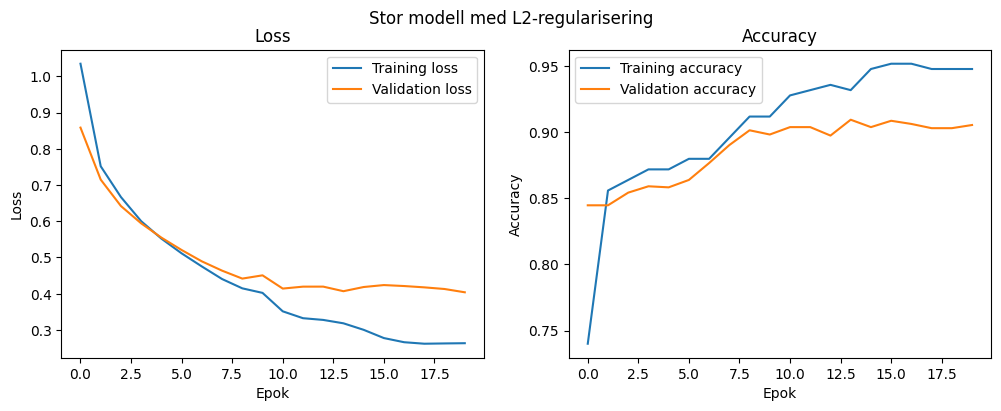

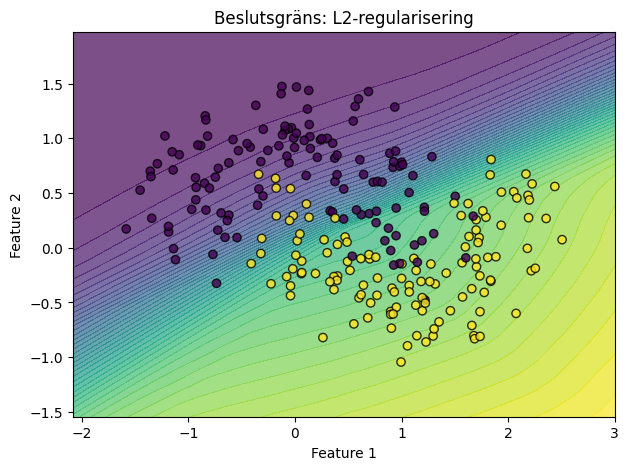

In [30]:
l2_model = build_model(
    hidden_layers=5,
    hidden_units=128,
    learning_rate=0.001,
    dropout_rate=0.0,
    l2_strength=0.001
)

l2_history, l2_result = run_experiment(
    name="Stor modell med L2-regularisering",
    model=l2_model,
    epochs=300,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0
)

results.append(l2_result)

plot_decision_boundary(
    l2_model,
    X_train,
    y_train,
    title="Beslutsgräns: L2-regularisering"
)

In [31]:
results_df = pd.DataFrame(results)

results_df.sort_values("test_accuracy", ascending=False)

,experiment,epochs_trained,test_loss,test_accuracy,training_time
1,Samma modell med early stopping,32,0.262579,0.900,3.429886
2,Stor modell med dropout,42,0.251787,0.894,4.725938
0,Stor modell utan regularisering,300,0.784547,0.892,27.533031
3,Stor modell med L2-regularisering,20,0.837700,0.866,2.423082


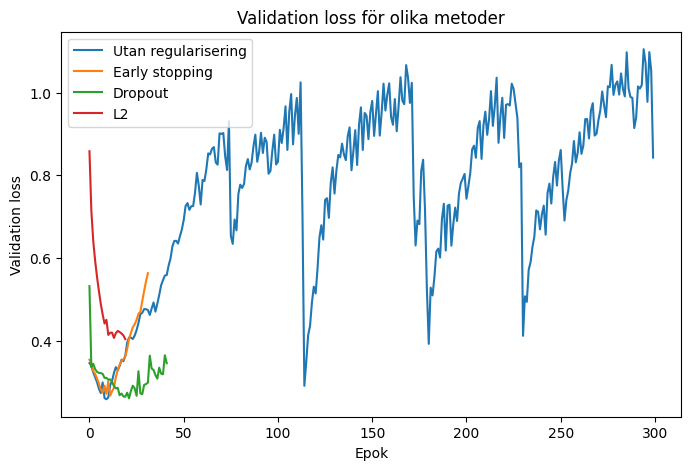

In [32]:
def plot_validation_losses(histories, labels, title="Validation loss jämförelse"):

    plt.figure(figsize=(8,5))

    for history, label in zip(histories, labels):
        plt.plot(history.history["val_loss"], label=label)

    plt.xlabel("Epok")
    plt.ylabel("Validation loss")
    plt.title(title)
    plt.legend()
    plt.show()

plot_validation_losses(
    histories=[
        overfit_history,
        early_stop_history,
        dropout_history,
        l2_history
    ],
    labels=[
        "Utan regularisering",
        "Early stopping",
        "Dropout",
        "L2"
    ],
    title="Validation loss för olika metoder"
)